In [16]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install graphviz

In [17]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [18]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad
from model.utils import *
from model.linear_model import LinearModel

import numpy as np
import matplotlib.pyplot as plt

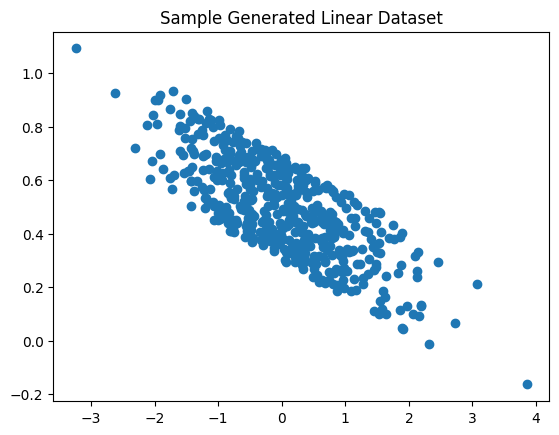

In [19]:
# Sample Code for generating datasets
seed = 42
np.random.seed(seed)

size = 500
dim = 1
noise_bound = 0.2

X, y, W = generate_linear_dataset(size, dim, noise_bound=noise_bound, is_reg=True)
plt.scatter(X[:, 1], y)
plt.title("Sample Generated Linear Dataset")
plt.show()


---
## Q1 (a and b) Learning Rate Experiment
---

---
### Dataset A - Load + Setup
---

In [20]:
# Dataset A
loaded_data = np.load('data/linear_data/linear_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset A | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42  # do not change the seed
np.random.seed(seed)

loss_fn = MSE
grad_fn = MSE_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset A | X size : (1600, 2), y size : (1600,)


---
### Dataset A - Lr Experiments
---


Dataset A | learning rate = 0.1
50. Training loss: 0.013423624195711394, Val loss:0.012580000493179293
100. Training loss: 0.013423622480987135, Val loss:0.01258008971226528
150. Training loss: 0.013423622480987133, Val loss:0.012580089715050556
200. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
250. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
300. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
350. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
400. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
450. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
500. Training loss: 0.013423622480987133, Val loss:0.012580089715050636


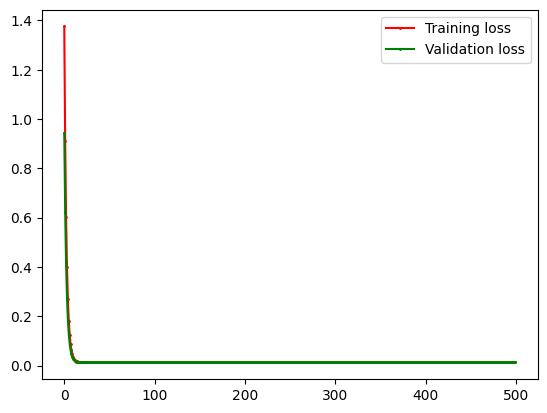

=== Linear Regression Evaluation | Dataset A | lr=0.1 ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690


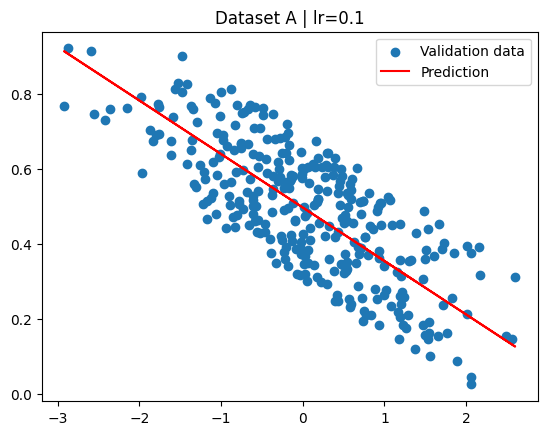


Dataset A | learning rate = 0.01
50. Training loss: 0.22389665936596015, Val loss:0.2222721701368548
100. Training loss: 0.04473791353662415, Val loss:0.043506871320832495
150. Training loss: 0.018083051477028683, Val loss:0.017079948707739195
200. Training loss: 0.014116985551358614, Val loss:0.013210362684918413
250. Training loss: 0.013526808616498798, Val loss:0.012658557107672769
300. Training loss: 0.013438979611857652, Val loss:0.012585780449882416
350. Training loss: 0.013425908200894933, Val loss:0.01257859777405428
400. Training loss: 0.013423962698572107, Val loss:0.012578954541903343
450. Training loss: 0.013423673122704472, Val loss:0.012579564566392844
500. Training loss: 0.013423630019323562, Val loss:0.012579872725242275


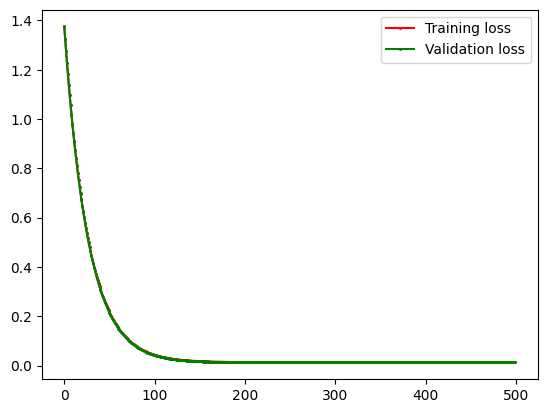

=== Linear Regression Evaluation | Dataset A | lr=0.01 ===
MSE       : 0.0134
MAE       : 0.1009
RMSE      : 0.1156
R-squared : 0.5690


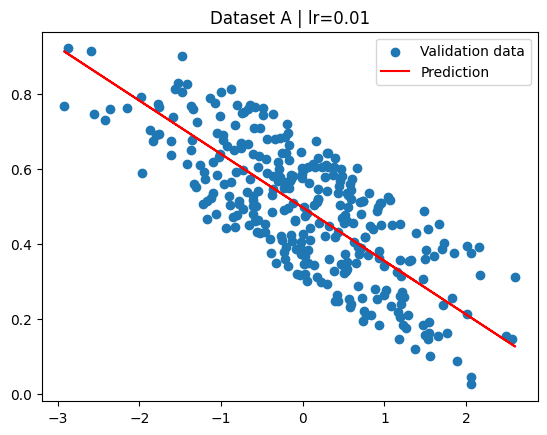


Dataset A | learning rate = 0.001
50. Training loss: 1.1451587601145723, Val loss:1.1835230479722467
100. Training loss: 0.9503348495853221, Val loss:0.9816866178920054
150. Training loss: 0.7890501237745033, Val loss:0.8146254353070983
200. Training loss: 0.6555305873763618, Val loss:0.6763491589866026
250. Training loss: 0.5449963105448375, Val loss:0.5618992520945488
300. Training loss: 0.45349028193283636, Val loss:0.467171262373702
350. Training loss: 0.37773672901734473, Val loss:0.38876771365113516
400. Training loss: 0.31502383196137185, Val loss:0.3238763358273957
450. Training loss: 0.2631066309126785, Val loss:0.27016926880823205
500. Training loss: 0.22012664984747138, Val loss:0.22571962766322928


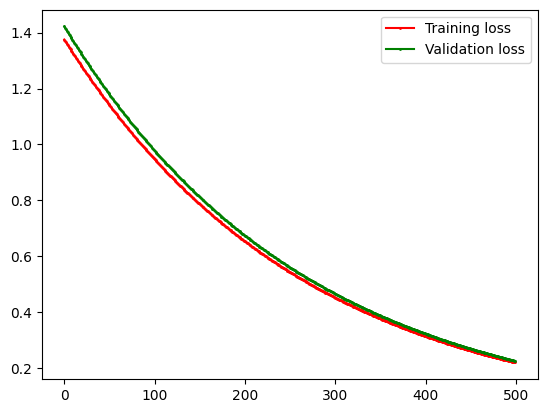

=== Linear Regression Evaluation | Dataset A | lr=0.001 ===
MSE       : 0.2201
MAE       : 0.3784
RMSE      : 0.4692
R-squared : -6.1039


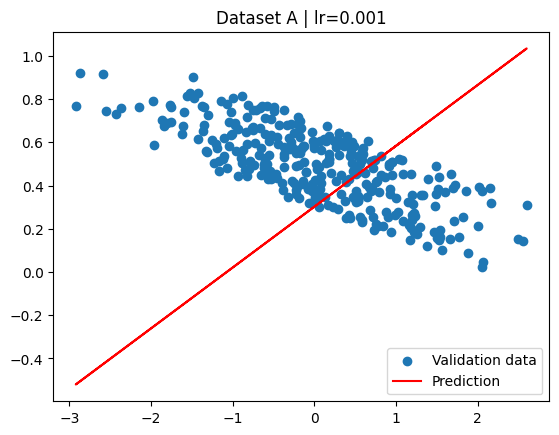

In [21]:
for lr in [0.1, 0.01, 0.001]:
    print("\n" + "=" * 80)
    print(f"Dataset A | learning rate = {lr}")
    print("=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, True, loss_fn, grad_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_linear_regression(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Linear Regression Evaluation | Dataset A | lr={lr}'
    )

    # Plot validation set and prediction line
    plt.scatter(X_val[:, 1], y_val, label='Validation data')
    plt.plot(X_val[:, 1], y_val_pred, label='Prediction', color='r')
    plt.title(f'Dataset A | lr={lr}')
    plt.legend()
    plt.show()

---
### Dataset B - Load + Setup
---

In [22]:
# Dataset B
loaded_data = np.load('data/linear_data/linear_data_B.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset B | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42  # do not change the seed
np.random.seed(seed)

loss_fn = MSE
grad_fn = MSE_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset B | X size : (1600, 2), y size : (1600,)


---
### Dataset B - Lr Experiments
---


Dataset B | learning rate = 0.1
50. Training loss: 0.21477796144802486, Val loss:0.20128107258989675
100. Training loss: 0.2147779596957941, Val loss:0.2012814354295645
150. Training loss: 0.2147779596957941, Val loss:0.20128143544080984
200. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
250. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
300. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
350. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
400. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
450. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
500. Training loss: 0.21477795969579408, Val loss:0.20128143544081017


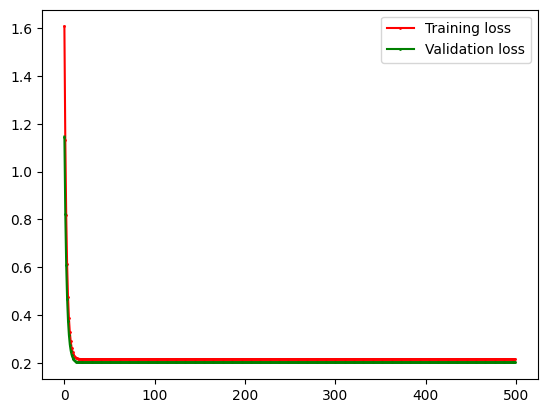

=== Linear Regression Evaluation | Dataset B | lr=0.1 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448


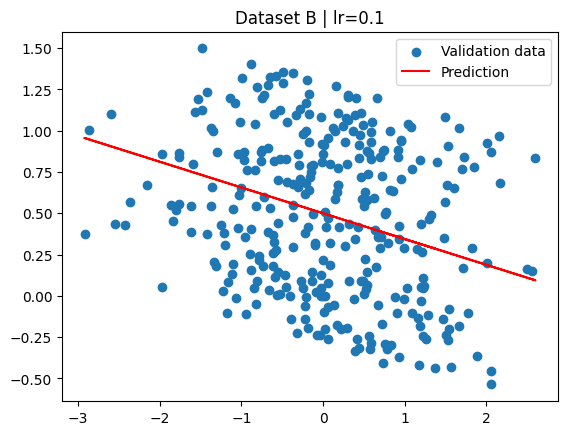


Dataset B | learning rate = 0.01
50. Training loss: 0.4299188642003233, Val loss:0.41262346230920866
100. Training loss: 0.24678509371162755, Val loss:0.23169138734722317
150. Training loss: 0.21954026986137268, Val loss:0.20540506306897865
200. Training loss: 0.21548660535060732, Val loss:0.20173821110472026
250. Training loss: 0.21488341671994743, Val loss:0.20128799970868744
300. Training loss: 0.2147936543580492, Val loss:0.20125837540069538
350. Training loss: 0.2147802955962557, Val loss:0.20126860352895581
400. Training loss: 0.21477830737521292, Val loss:0.20127585342238596
450. Training loss: 0.2147780114472797, Val loss:0.20127917145941843
500. Training loss: 0.21477796739920696, Val loss:0.20128053965605247


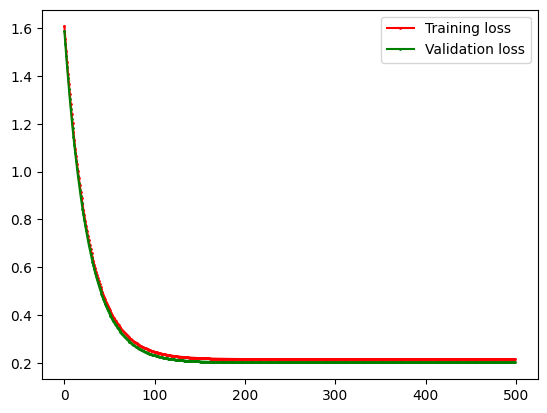

=== Linear Regression Evaluation | Dataset B | lr=0.01 ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448


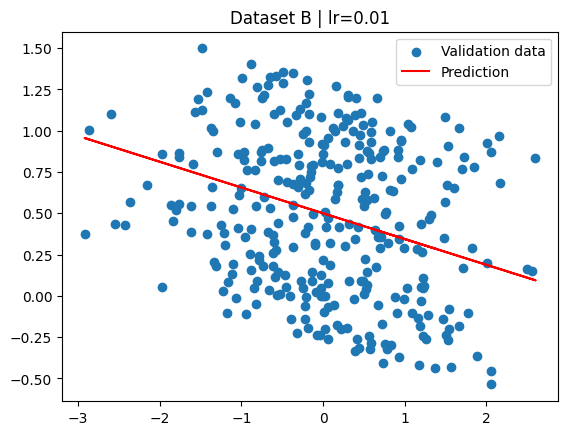


Dataset B | learning rate = 0.001
50. Training loss: 1.371673141563389, Val loss:1.3915690411645854
100. Training loss: 1.1725121323450383, Val loss:1.185792500400312
150. Training loss: 1.0076380300479466, Val loss:1.0155240745606382
200. Training loss: 0.8711479141554356, Val loss:0.8746422988297105
250. Training loss: 0.7581551624933356, Val loss:0.7580805514604568
300. Training loss: 0.6646144696871166, Val loss:0.6616453213702442
350. Training loss: 0.5871769943729133, Val loss:0.581865782946438
400. Training loss: 0.5230704472905523, Val loss:0.5158692847835491
450. Training loss: 0.4699998257287622, Val loss:0.46127828819686856
500. Training loss: 0.42606523929518103, Val loss:0.4161250604089985


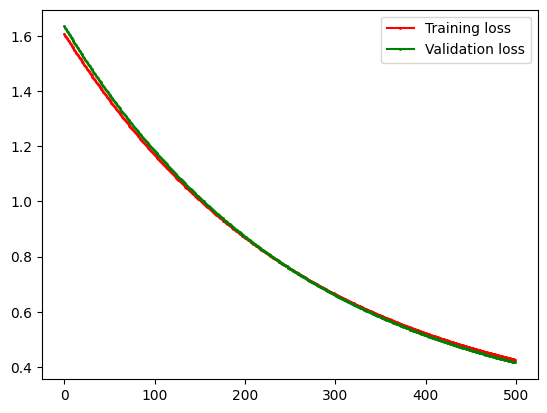

=== Linear Regression Evaluation | Dataset B | lr=0.001 ===
MSE       : 0.3920
MAE       : 0.5172
RMSE      : 0.6261
R-squared : -0.7521


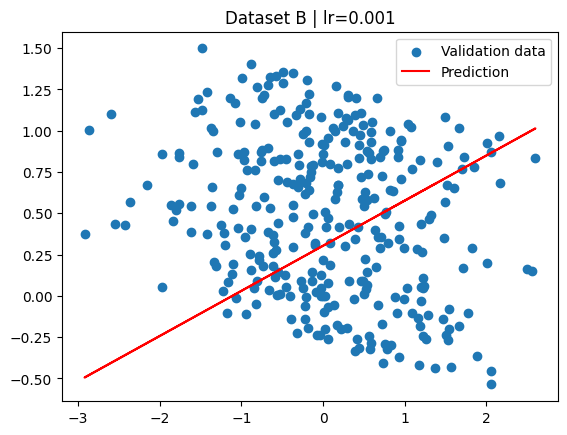

In [23]:
for lr in [0.1, 0.01, 0.001]:
    print("\n" + "=" * 80)
    print(f"Dataset B | learning rate = {lr}")
    print("=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, True, loss_fn, grad_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_linear_regression(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Linear Regression Evaluation | Dataset B | lr={lr}'
    )

    # Plot validation set and prediction line
    plt.scatter(X_val[:, 1], y_val, label='Validation data')
    plt.plot(X_val[:, 1], y_val_pred, label='Prediction', color='r')
    plt.title(f'Dataset B | lr={lr}')
    plt.legend()
    plt.show()

---
### Dataset C - Load + Setup
---

In [24]:
# Dataset C
loaded_data = np.load('data/linear_data/linear_data_C.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset C | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42  # do not change the seed
np.random.seed(seed)

loss_fn = MSE
grad_fn = MSE_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset C | X size : (8000, 6), y size : (8000,)


---
### Dataset C - Lr Experiments
---


Dataset C | learning rate = 0.1
50. Training loss: 0.013181897270033976, Val loss:0.013771652595846461
100. Training loss: 0.013181896123422136, Val loss:0.013771595669664214
150. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
200. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
250. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
300. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
350. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
400. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
450. Training loss: 0.013181896123422132, Val loss:0.013771595669175307
500. Training loss: 0.013181896123422132, Val loss:0.013771595669175307


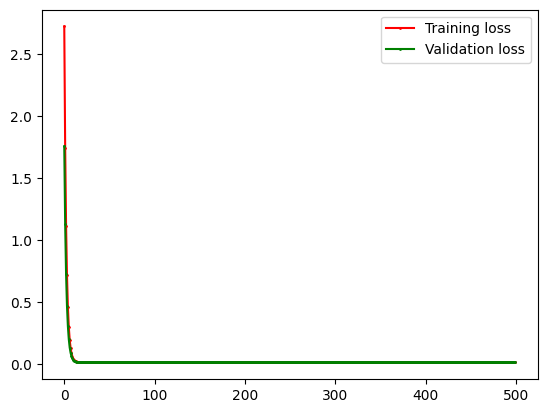

=== Linear Regression Evaluation | Dataset C | lr=0.1 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954

Dataset C | learning rate = 0.01
50. Training loss: 0.3834064687672843, Val loss:0.3745814274228055
100. Training loss: 0.062111774211928886, Val loss:0.06210346546216219
150. Training loss: 0.01969653991883922, Val loss:0.02038318720708201
200. Training loss: 0.014055391174225117, Val loss:0.014714182021595263
250. Training loss: 0.013299793038899596, Val loss:0.013917899701948611
300. Training loss: 0.013197907098696778, Val loss:0.013798129358983169
350. Training loss: 0.013184082868757458, Val loss:0.013777569708506562
400. Training loss: 0.013182196339278432, Val loss:0.013773247256172377
450. Training loss: 0.013181937534687466, Val loss:0.013772117929029954
500. Training loss: 0.013181901860051387, Val loss:0.013771772309477844


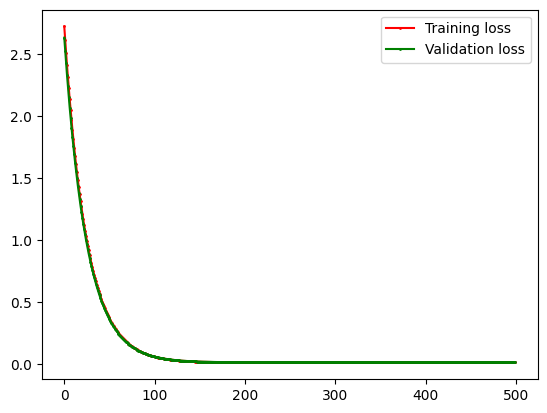

=== Linear Regression Evaluation | Dataset C | lr=0.01 ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954

Dataset C | learning rate = 0.001
50. Training loss: 2.23749294593451, Val loss:2.2452669406506325
100. Training loss: 1.8314850269989826, Val loss:1.8392619038321811
150. Training loss: 1.4996985687921305, Val loss:1.5072687345106885
200. Training loss: 1.2285447253189052, Val loss:1.2357723924262496
250. Training loss: 1.0069263407337483, Val loss:1.0137297449309415
300. Training loss: 0.825780374257102, Val loss:0.8321167523799234
350. Training loss: 0.6777044809357149, Val loss:0.6835587279047317
400. Training loss: 0.5566522474252956, Val loss:0.5620284077740394
450. Training loss: 0.45768444132135555, Val loss:0.46259937720449595
500. Training loss: 0.37676596369426263, Val loss:0.3812446875725488


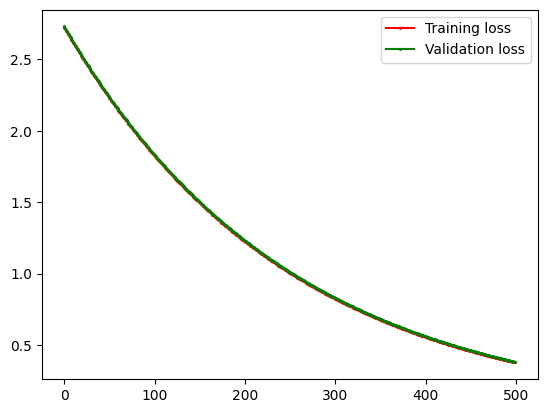

=== Linear Regression Evaluation | Dataset C | lr=0.001 ===
MSE       : 0.3796
MAE       : 0.5018
RMSE      : 0.6161
R-squared : 0.8662


In [25]:
for lr in [0.1, 0.01, 0.001]:
    print("\n" + "=" * 80)
    print(f"Dataset C | learning rate = {lr}")
    print("=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, True, loss_fn, grad_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_linear_regression(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Linear Regression Evaluation | Dataset C | lr={lr}'
    )

---
### Dataset D - Load + Setup
---

In [26]:
# Dataset D
loaded_data = np.load('data/linear_data/linear_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

print(f"Dataset D | X size : {X.shape}, y size : {y.shape}")

size = X.shape[0]
dim = X.shape[1] - 1

seed = 42  # do not change the seed
np.random.seed(seed)

loss_fn = MSE
grad_fn = MSE_grad

X_train, y_train, X_val, y_val = get_train_val(X, y)

Dataset D | X size : (8000, 6), y size : (8000,)


---
### Dataset D - Lr Experiments
---


Dataset D | learning rate = 0.1
50. Training loss: 0.08238685191582185, Val loss:0.08607261439253647
100. Training loss: 0.08238685077138833, Val loss:0.08607247293357059
150. Training loss: 0.08238685077138833, Val loss:0.08607247293234568
200. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
250. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
300. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
350. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
400. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
450. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
500. Training loss: 0.08238685077138833, Val loss:0.0860724729323457


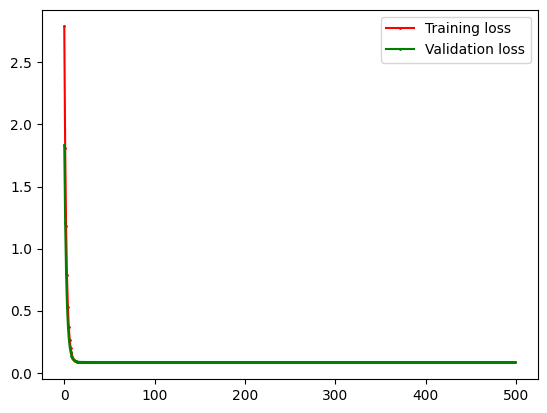

=== Linear Regression Evaluation | Dataset D | lr=0.1 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716

Dataset D | learning rate = 0.01
50. Training loss: 0.4521557533129249, Val loss:0.4492723976254024
100. Training loss: 0.13125317194658065, Val loss:0.1353504662562722
150. Training loss: 0.08889257553525287, Val loss:0.09303386641349547
200. Training loss: 0.08325908820943473, Val loss:0.08714130929386563
250. Training loss: 0.0825045697101425, Val loss:0.08626393148345575
300. Training loss: 0.08240283649089146, Val loss:0.08611509991475105
350. Training loss: 0.08238903392577364, Val loss:0.08608417452979802
400. Training loss: 0.08238715047597851, Val loss:0.08607616156356238
450. Training loss: 0.08238689210979702, Val loss:0.08607371934722588
500. Training loss: 0.08238685649762986, Val loss:0.08607290688511911


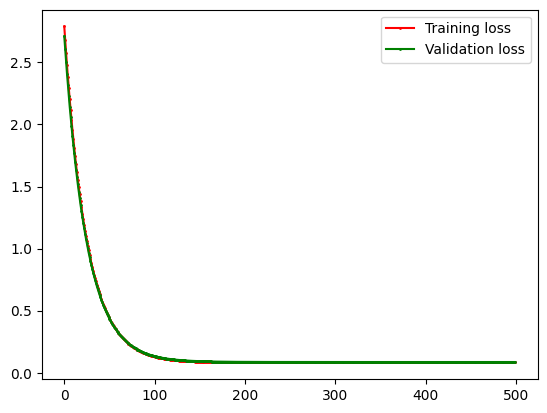

=== Linear Regression Evaluation | Dataset D | lr=0.01 ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716

Dataset D | learning rate = 0.001
50. Training loss: 2.304087892398808, Val loss:2.322128048766163
100. Training loss: 1.8985450836883995, Val loss:1.9158913872329326
150. Training loss: 1.5671407025131152, Val loss:1.583651269816583
200. Training loss: 1.2963007550181984, Val loss:1.311900911601199
250. Training loss: 1.0749402753827337, Val loss:1.089603421914175
300. Training loss: 0.8940062289510703, Val loss:0.9077394024588823
350. Training loss: 0.746104485102115, Val loss:0.7589375407399721
400. Training loss: 0.6251953745771189, Val loss:0.6371729496861158
450. Training loss: 0.5263452025213163, Val loss:0.5375208103389396
500. Training loss: 0.4455234173227705, Val loss:0.4559551633623019


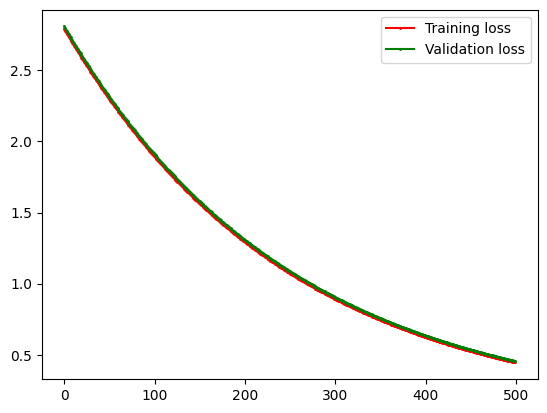

=== Linear Regression Evaluation | Dataset D | lr=0.001 ===
MSE       : 0.4475
MAE       : 0.5415
RMSE      : 0.6690
R-squared : 0.8458


In [27]:
for lr in [0.1, 0.01, 0.001]:
    print("\n" + "=" * 80)
    print(f"Dataset D | learning rate = {lr}")
    print("=" * 80)

    np.random.seed(seed)

    model = LinearModel(dim, True, loss_fn, grad_fn)
    model.fit(X_train, y_train, lr=lr, n_iteration=500, val_ratio=0.2)

    y_val_pred = model.predict(X_val)

    evaluate_linear_regression(
        y_true=y_val,
        y_pred=y_val_pred,
        title=f'Linear Regression Evaluation | Dataset D | lr={lr}'
    )